In [7]:
import sys
sys.path.append('..') 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_processor import ComplaintDataProcessor, TARGET_PRODUCTS, NARRATIVE_COL

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# Initialize the processor
processor = ComplaintDataProcessor()

In [8]:
# This takes less than a second even on a 10GB file
df_peek = pd.read_csv('../data/raw/complaints.csv', nrows=5)

print("Available Columns:", df_peek.columns.tolist())
display(df_peek.head(2))
print(f"\nData types:")
print(df_peek.dtypes)

Available Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688



Data types:
Date received                       str
Product                             str
Sub-product                         str
Issue                               str
Sub-issue                           str
Consumer complaint narrative    float64
Company public response             str
Company                             str
State                               str
ZIP code                            str
Tags                            float64
Consumer consent provided?      float64
Submitted via                       str
Date sent to company                str
Company response to consumer        str
Timely response?                    str
Consumer disputed?              float64
Complaint ID                      int64
dtype: object


#### Load and Filter dataset with only Specified Products(Credit Cards, Personal Loans, Savings Accounts, Money Transfers)

In [3]:
# Cell 3: Load and filter
print("\n" + "="*60)
print("STEP 2: LOAD AND FILTER")
print("="*60)

filtered_df = processor.load_and_filter_dataset()
print(f"\nFiltered: {len(filtered_df):,} records")


STEP 2: LOAD AND FILTER
Processing ../data/raw/complaints.csv in chunks...
Chunk size: 100,000 rows
------------------------------------------------------------
  Processed 1,000,000 rows... (kept 45,133 so far)
  Processed 2,000,000 rows... (kept 109,709 so far)
  Processed 3,000,000 rows... (kept 172,847 so far)
  Processed 4,000,000 rows... (kept 248,107 so far)
  Processed 5,000,000 rows... (kept 346,871 so far)
  Processed 6,000,000 rows... (kept 473,605 so far)
  Processed 7,000,000 rows... (kept 600,749 so far)
  Processed 8,000,000 rows... (kept 719,758 so far)
  Processed 9,000,000 rows... (kept 803,755 so far)
------------------------------------------------------------
Processed 9,609,797 rows across 97 chunks
Kept 885,813 records for target products
Final filtered dataset: 885,813 records

Category Breakdown:
  Credit Cards: 433,055 (48.9%)
  Savings Accounts: 291,178 (32.9%)
  Money Transfers: 145,066 (16.4%)
  Personal Loans: 16,514 (1.9%)

Filtered: 885,813 records


#### CLEANING the NARRATIVES

In [5]:
cleaned_df = processor.clean_narratives()

print(f"\n Cleaned dataset: {len(cleaned_df):,} records")
print(f"   (Removed {len(filtered_df) - len(cleaned_df):,} records without narratives)")


CLEANING NARRATIVES
Starting with 885,813 records
  Applying text cleaning...
  Removing empty narratives...
  Removed 450,076 empty records
  Adding word count...

 Cleaned dataset: 435,737 records

Category Breakdown (Cleaned):
  Credit Cards: 189,334 (43.5%)
  Savings Accounts: 140,319 (32.2%)
  Money Transfers: 97,188 (22.3%)
  Personal Loans: 8,896 (2.0%)

 Cleaned dataset: 435,737 records
   (Removed 450,076 records without narratives)


In [23]:
print("\n" + "="*60)
print("CLEANED DATASET ANALYSIS")
print("="*60)

# Show cleaned data sample
print("Sample of cleaned narratives:")
print(f"columns: {cleaned_df.columns.tolist()}")
display(cleaned_df[['Product', 'Issue', 'narrative', 'word_count']].head())


CLEANED DATASET ANALYSIS
Sample of cleaned narratives:
columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID', 'Product_Category', 'narrative', 'word_count', 'date_received', 'year', 'month', 'quarter', 'length_category']


,Product,Issue,narrative,word_count
127,Credit card,Getting a credit card,a xxxx xxxx card was opened under my name by a...,91
138,Checking or savings account,Managing an account,i made the mistake of using my wellsfargo debi...,108
149,Credit card,"Other features, terms, or problems",i have a secured credit card with citibank whi...,154
155,Credit card,Incorrect information on your report,i have a citi rewards cards. the credit balanc...,230
173,Credit card,Problem with a purchase shown on your statement,b'i am writing to dispute the following charge...,500



Word count statistics:
count    435737.000000
mean        205.681925
std         228.619619
min           1.000000
25%          83.000000
50%         137.000000
75%         256.000000
max        6472.000000
Name: word_count, dtype: float64

Word count by Product Category:
                     count        mean         std  min   25%    50%    75%  \
Product_Category                                                              
Credit Cards      189334.0  214.156982  228.645813  1.0  77.0  155.0  273.0   
Money Transfers    97188.0  166.808382  201.742734  1.0  95.0  103.0  180.0   
Personal Loans      8896.0  201.963354  233.271229  3.0  71.0  141.5  253.0   
Savings Accounts  140319.0  221.406852  242.353762  1.0  77.0  154.0  277.0   

                     max  
Product_Category          
Credit Cards      6472.0  
Money Transfers   5603.0  
Personal Loans    5670.0  
Savings Accounts  5941.0  


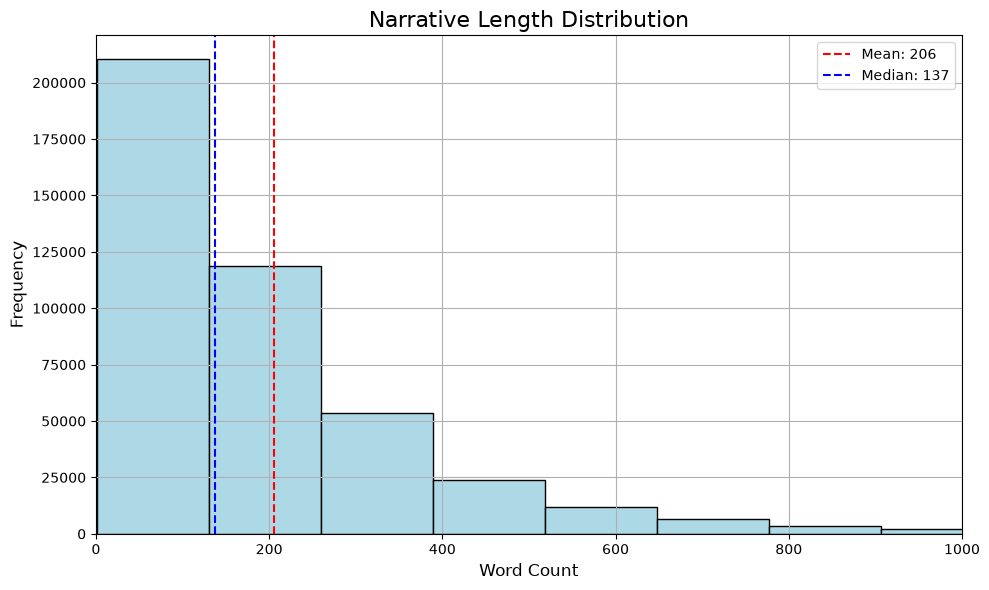

In [9]:
# Word count statistics
print("\nWord count statistics:")
print(cleaned_df['word_count'].describe())

# Word count distribution by category (summary table)
print("\nWord count by Product Category:")
print(cleaned_df.groupby('Product_Category')['word_count'].describe())

# Single histogram with distribution
fig, ax = plt.subplots(figsize=(10, 6))

cleaned_df['word_count'].hist(bins=50, ax=ax, color='lightblue', edgecolor='black')
ax.axvline(cleaned_df['word_count'].mean(), color='red', 
           linestyle='--', label=f'Mean: {cleaned_df["word_count"].mean():.0f}')
ax.axvline(cleaned_df['word_count'].median(), color='blue', 
           linestyle='--', label=f'Median: {cleaned_df["word_count"].median():.0f}')
ax.set_title('Narrative Length Distribution', fontsize=16)
ax.set_xlabel('Word Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
ax.set_xlim(0, 1000)

plt.tight_layout()
plt.show()


PRODUCT CATEGORY DISTRIBUTION
                  Total Records  With Narratives  Kept %
Product_Category                                        
Credit Cards             433055           189334    43.7
Savings Accounts         291178           140319    48.2
Money Transfers          145066            97188    67.0
Personal Loans            16514             8896    53.9


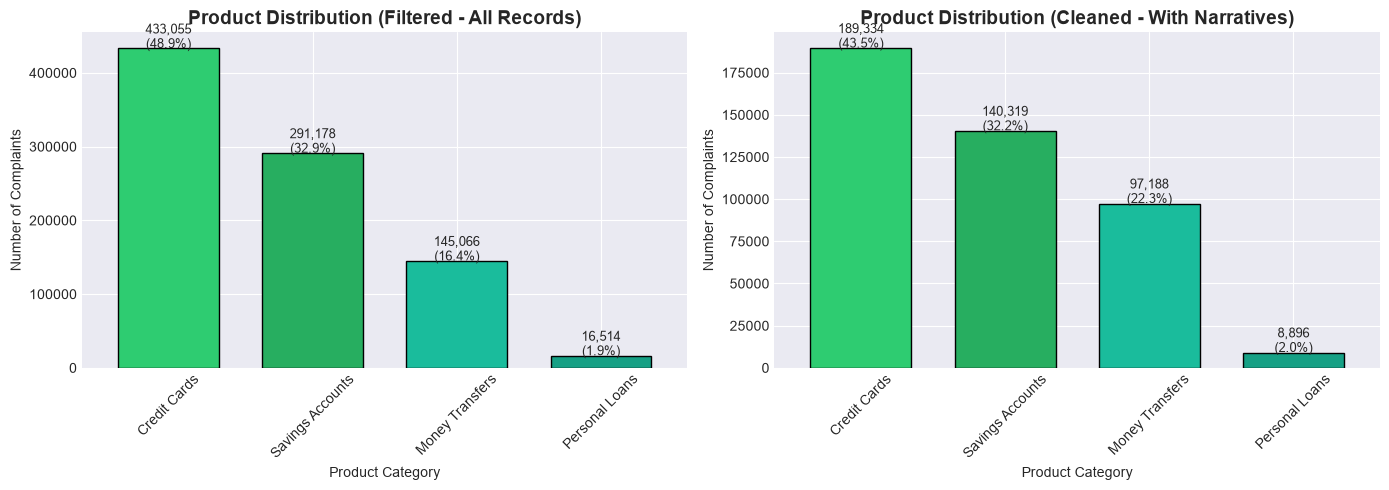

In [13]:
# Product Category Distribution
print("\n" + "="*60)
print("PRODUCT CATEGORY DISTRIBUTION")
print("="*60)

# Before and after cleaning
cat_before = filtered_df['Product_Category'].value_counts()
cat_after = cleaned_df['Product_Category'].value_counts()

comparison_df = pd.DataFrame({
    'Total Records': cat_before,
    'With Narratives': cat_after,
    'Kept %': (cat_after / cat_before * 100).round(1)
})
print(comparison_df)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
colors = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
cat_before.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.7)
axes[0].set_title('Product Distribution (Filtered - All Records)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cat_before.values):
    pct = v / cat_before.sum() * 100
    axes[0].text(i, v + 500, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)

# After cleaning
cat_after.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', width=0.7)
axes[1].set_title('Product Distribution (Cleaned - With Narratives)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Number of Complaints')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(cat_after.values):
    pct = v / cat_after.sum() * 100
    axes[1].text(i, v + 500, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


COMPANY ANALYSIS
Top 10 Companies:
Company
Block, Inc.                              37709
JPMORGAN CHASE & CO.                     36863
CAPITAL ONE FINANCIAL CORPORATION        32527
CITIBANK, N.A.                           32499
BANK OF AMERICA, NATIONAL ASSOCIATION    31567
WELLS FARGO & COMPANY                    26800
Early Warning Services, LLC              17284
SYNCHRONY FINANCIAL                      16902
Paypal Holdings, Inc                     13948
AMERICAN EXPRESS COMPANY                 13605
Name: count, dtype: int64


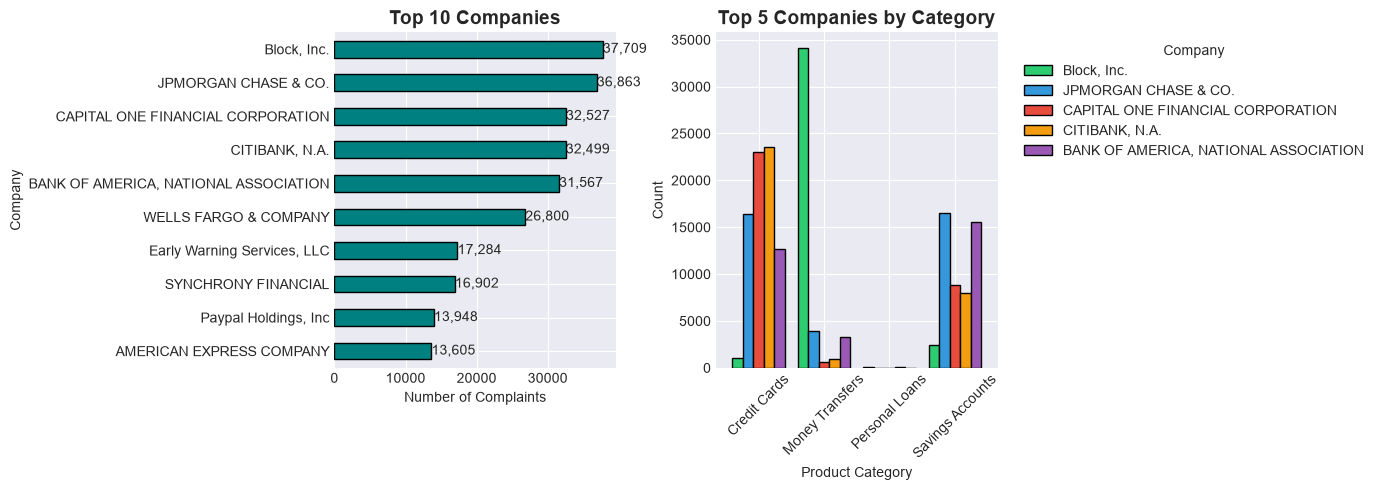

In [29]:
#  Company Analysis
print("\n" + "="*60)
print("COMPANY ANALYSIS")
print("="*60)


# Top companies
top_companies = cleaned_df['Company'].value_counts().head(10)
print("Top 10 Companies:")
print(top_companies)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Top 10 Companies - Horizontal bar (cleaner)
top_companies_sorted = top_companies.sort_values()
top_companies_sorted.plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Top 10 Companies', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
for i, v in enumerate(top_companies_sorted.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=10)

# 2. Company by Category - Simple grouped bar
top_5_companies = cleaned_df['Company'].value_counts().head(5).index
company_by_cat = cleaned_df.groupby(['Product_Category', 'Company']).size().unstack(fill_value=0)
company_by_cat_top = company_by_cat[top_5_companies]

# Plot
company_by_cat_top.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'], 
                        edgecolor='black', width=0.8)
axes[1].set_title('Top 5 Companies by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Count')
axes[1].legend(title='Company', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [30]:
# Issue Analysis
print("\n" + "="*60)
print("ISSUE ANALYSIS")
print("="*60)

processor.get_issue_distribution(cleaned_df)


ISSUE ANALYSIS


Issue
Managing an account                                  75712
Other transaction problem                            49431
Problem with a purchase shown on your statement      40497
Fraud or scam                                        19768
Other features, terms, or problems                   19662
                                                     ...  
Credit limit changed                                    29
Was approved for a loan, but didn't receive money       22
Lost or stolen refund                                    4
Problem with an overdraft                                4
Property was sold                                        3
Name: count, Length: 96, dtype: int64


DATE ANALYSIS
Complaints by Year:
year
2015     6243
2016     9433
2017    17560
2018    22094
2019    22716
2020    31460
2021    36974
2022    47420
2023    72166
2024    80409
2025    89262
Name: count, dtype: int64


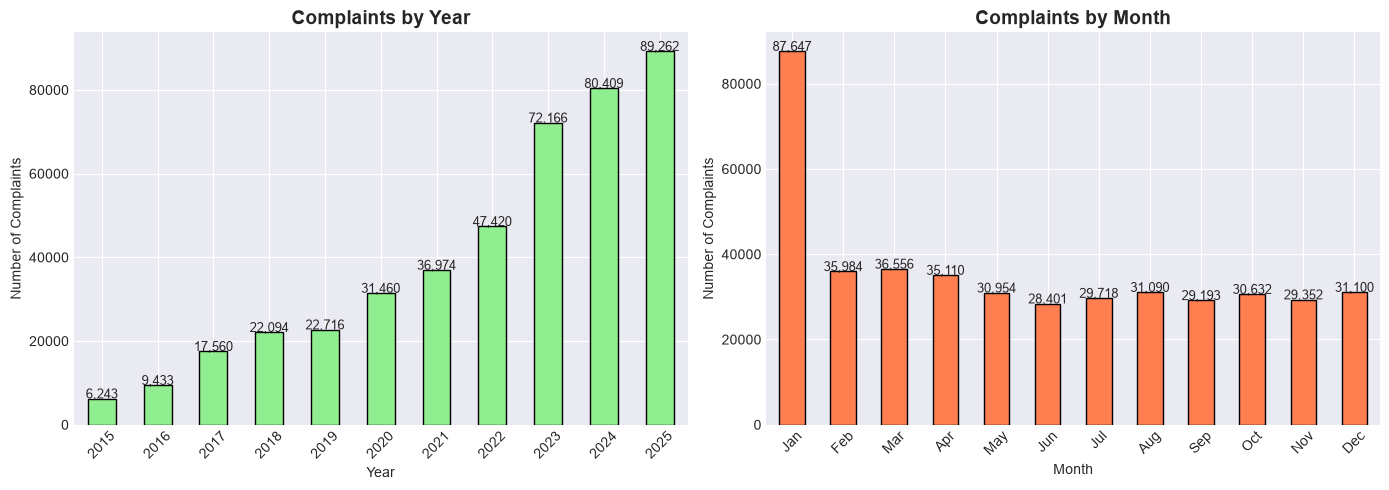


Quarterly Distribution:
quarter
1    160187
2     94465
3     90001
4     91084
Name: count, dtype: int64


In [11]:
# Cell 13: Date/Time Analysis
print("\n" + "="*60)
print("DATE ANALYSIS")
print("="*60)

# Convert date to datetime
cleaned_df['date_received'] = pd.to_datetime(cleaned_df['Date received'])

# Add time features
cleaned_df['year'] = cleaned_df['date_received'].dt.year
cleaned_df['month'] = cleaned_df['date_received'].dt.month
cleaned_df['quarter'] = cleaned_df['date_received'].dt.quarter

# Complaints by year
year_counts = cleaned_df['year'].value_counts().sort_index()
print("Complaints by Year:")
print(year_counts)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly trend
year_counts.plot(kind='bar', ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Complaints by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(year_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Monthly distribution
monthly_counts = cleaned_df['month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts.index = month_names
monthly_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Complaints by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Complaints')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(monthly_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Quarterly trend
print("\nQuarterly Distribution:")
print(cleaned_df['quarter'].value_counts().sort_index())


STATE ANALYSIS
Top 10 States:
State
CA    59161
TX    39047
FL    38501
NY    31583
IL    23094
GA    21171
PA    16365
NJ    15176
NC    13078
VA    12492
Name: count, dtype: int64


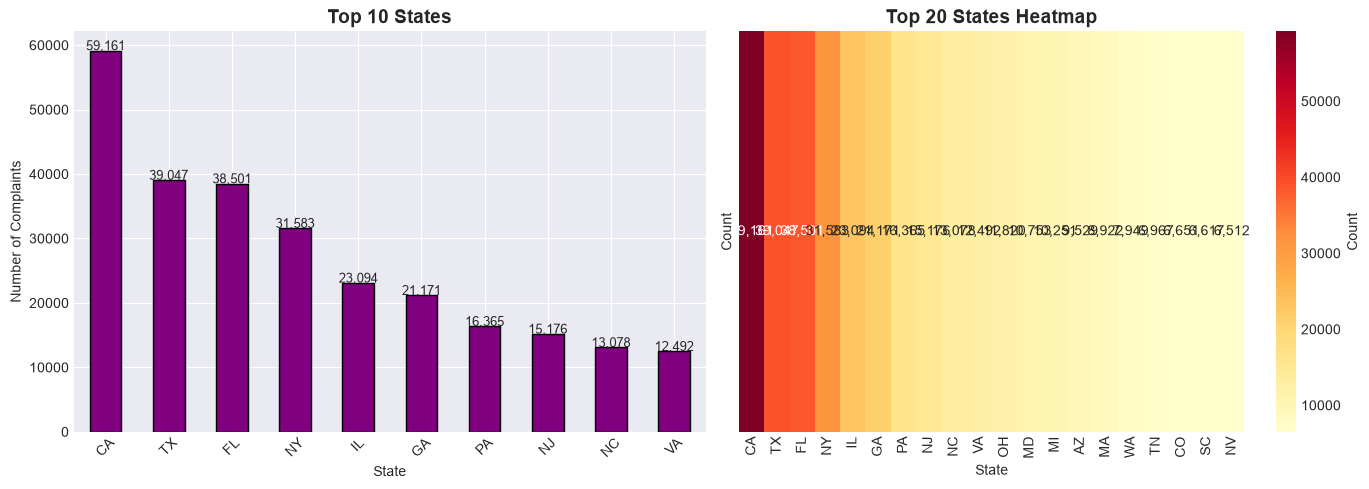

In [16]:
# State Analysis
print("\n" + "="*60)
print("STATE ANALYSIS")
print("="*60)

# Top states
top_states = cleaned_df['State'].value_counts().head(10)
print("Top 10 States:")
print(top_states)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top states
top_states.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Top 10 States', fontsize=14, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(top_states.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# State heatmap (top 20 states)
state_counts = cleaned_df['State'].value_counts().head(20)
state_counts_df = pd.DataFrame({'Count': state_counts})
sns.heatmap(state_counts_df.T, annot=True, fmt=',d', ax=axes[1], cmap='YlOrRd', cbar_kws={'label': 'Count'})
axes[1].set_title('Top 20 States Heatmap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('State')

plt.tight_layout()
plt.show()


NARRATIVE QUALITY ANALYSIS
Narrative Length Categories:
length_category
Short (51-150)       177471
Medium (151-300)     117153
Very Short (1-50)     57291
Long (301-500)        52849
Very Long (500+)      30973
Name: count, dtype: int64


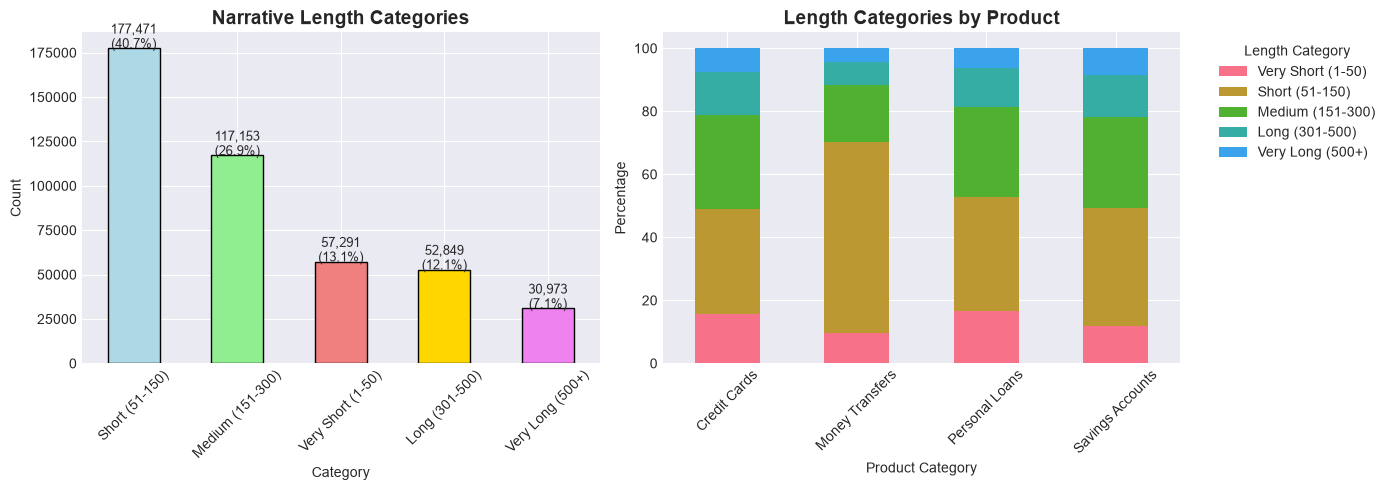

In [17]:
# Narrative Quality Analysis
print("\n" + "="*60)
print("NARRATIVE QUALITY ANALYSIS")
print("="*60)

# Length categories
cleaned_df['length_category'] = pd.cut(
    cleaned_df['word_count'],
    bins=[0, 50, 150, 300, 500, float('inf')],
    labels=['Very Short (1-50)', 'Short (51-150)', 'Medium (151-300)', 
            'Long (301-500)', 'Very Long (500+)']
)

length_dist = cleaned_df['length_category'].value_counts()
print("Narrative Length Categories:")
print(length_dist)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length categories
length_dist.plot(kind='bar', ax=axes[0], color=['lightblue', 'lightgreen', 'lightcoral', 'gold', 'violet'], 
                 edgecolor='black')
axes[0].set_title('Narrative Length Categories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(length_dist.values):
    pct = v / len(cleaned_df) * 100
    axes[0].text(i, v + 100, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)

# Length categories by product
length_by_cat = pd.crosstab(cleaned_df['Product_Category'], cleaned_df['length_category'], normalize='index') * 100
length_by_cat.plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Length Categories by Product', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Length Category', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Cell: Check what data you have
print("="*60)
print("DATA STATE CHECK")
print("="*60)

# Check processor state
print(f"processor.filtered_df: {processor.filtered_df is not None}")
if processor.filtered_df is not None:
    print(f"  Filtered records: {len(processor.filtered_df):,}")

print(f"processor.cleaned_df: {processor.cleaned_df is not None}")
if processor.cleaned_df is not None:
    print(f"  Cleaned records: {len(processor.cleaned_df):,}")

# Check if cleaned_df exists in local variables
if 'cleaned_df' in locals():
    print(f"\ncleaned_df in locals: {len(cleaned_df):,} records")
else:
    print("\ncleaned_df not found in locals")

DATA STATE CHECK
processor.filtered_df: False
processor.cleaned_df: False

cleaned_df in locals: 435,737 records


#### Save the filtered and cleaned dataset

In [32]:
OUTPUT_COLUMNS = [
    'Complaint ID',
    'Product_Category',
    'Product',
    'Issue',
    'Sub-issue',
    'Company',
    'State',
    'Date received',
    'narrative'
]

cleaned_df[OUTPUT_COLUMNS].to_csv('../data/processed/filtered_complaints.csv', index=False)

print(f" Saved {len(cleaned_df):,} records")

 Saved 435,737 records


## Key visualization Insights Summary

### 1. Product Distribution
- **Credit Cards dominate** (48.9% of filtered complaints), followed by Savings Accounts (32.9%), Money Transfers (16.4%), and Personal Loans (1.9%)
- **Money Transfers** have highest narrative coverage (67.0%), suggesting customers provide detailed descriptions for transfer issues
- **Personal Loans** are severely underrepresented (only 1.9%), requiring careful sampling for balanced RAG retrieval

### 2. Narrative Quality
- **Average length**: 206 words (range: 1-6,472), median: 137 words
- **40.7%** of narratives are short (51-150 words) - most complaints are concise
- **26.9%** are medium length (151-300 words) - sufficient detail for semantic analysis
- **Good overall quality**: 73.6% of narratives are at least 51 words, suitable for embedding

### 3. Top Issues
- **Managing an account** (17.4%) and **Transaction problems** (20.6%) dominate complaint types
- Fraud/Scam complaints represent 4.5% - critical for risk monitoring
- Top 5 issues account for **46% of all complaints**

### 4. Company Concentration
- Top 5 companies (Block, Chase, Capital One, Citi, BofA) represent **~39% of all complaints**
- Major banks dominate across multiple product categories
- Fintech (Block, PayPal) appears prominently in Money Transfers

### 5. Geographic & Temporal Trends
- **CA, TX, FL, NY** account for 38.6% of all complaints
- Complaints **grew 14x** from 2015 to 2025 (6,243 → 89,262)
- **Q1 peak**: 36.8% of complaints occur in Q1, suggesting post-holiday financial strain
- Recent surge (2023-2025) indicates growing customer engagement or emerging issues

### 6. Data Quality Insights
- **49.2%** of filtered complaints contain narratives (435,737 records)
- **Savings Accounts** have longest average narratives (221 words)
- **Money Transfers** have shortest average narratives (167 words) but best coverage
- Narrative lengths range widely (1-6,472 words), requiring adaptive chunking

### Recommendations for RAG Pipeline
1. **Stratified sampling** needed due to product imbalance (Personal Loans severely underrepresented)
2. **Focus on Account Management & Transaction issues** as they dominate complaint types
3. **Metadata inclusion**: Product category, issue type, company, state for filtering
4. **Weight recent complaints** (2023-2025) for current issue detection
5. **500-character chunks with 50-character overlap** to handle variable narrative lengths